# **MÓDULO 14 - Exercício**
# Pré-processamento dos Dados - Primeira etapa Pré-Modelagem

Base utilizada: **CHURN_TELECON_MOD08_TAREFA.csv**

Neste notebook realizei a primeira etapa de pré-modelagem da base de churn de telecomunicações. O objetivo foi carregar a base, verificar tipos de dados, identificar dados faltantes, tratar valores ausentes e corrigir inconsistências em variáveis categóricas.

## Contexto da base

A base representa clientes de uma empresa de telecomunicações. A variável mais importante é **Churn**, que indica se o cliente abandonou ou não o serviço.

Principais variáveis:

* **customerID**: identificação única do cliente.
* **Genero**: gênero do cliente.
* **Idoso**: indica se o cliente tem mais de 60 anos. `1 = Sim` e `0 = Não`.
* **Casado**: indica se o cliente é casado.
* **Dependents**: indica se o cliente possui dependentes.
* **Tempo_como_Cliente**: tempo do cliente na empresa, em meses.
* **PhoneService**: indica se o cliente possui serviço telefônico.
* **Servico_Internet**: tipo de serviço de internet contratado.
* **Servico_Seguranca**: indica se contratou serviço de segurança.
* **Suporte_Tecnico**: indica se já acionou ou possui suporte técnico.
* **StreamingTV**: indica se possui serviço de streaming de TV.
* **Tipo_Contrato**: tipo de contrato do cliente.
* **PaymentMethod**: forma de pagamento.
* **Pagamento_Mensal**: valor pago mensalmente pelo cliente.
* **Total_Pago**: total acumulado pago pelo cliente.
* **Churn**: indica se o cliente abandonou ou não o serviço.

In [1]:
# Importação das principais bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
# Leitura da base de dados
# O arquivo está separado por ponto e vírgula (;), por isso usei delimiter=';'.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';', encoding='utf-8-sig')

# Visualizando as primeiras linhas
df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,"1,889.50",No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,"1,840.75",No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,"1,949.40",NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,"3,046.05",NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,"3,487.95",NaN


In [3]:
# Conferindo o tamanho da base
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 2500
Quantidade de colunas: 16


# 1 - Carregamento da base e verificação dos tipos de dados

Nesta etapa, verifiquei os tipos de dados de cada coluna para entender se estavam compatíveis com a informação representada. Também conferi se havia identificadores duplicados.

In [4]:
# Verificando os tipos de dados e quantidade de valores não nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          2500 non-null   object 
 1   Genero              2488 non-null   object 
 2   Idoso               2500 non-null   int64  
 3   Casado              2500 non-null   object 
 4   Dependents          2500 non-null   object 
 5   Tempo_como_Cliente  2500 non-null   int64  
 6   PhoneService        1018 non-null   object 
 7   Servico_Internet    2500 non-null   object 
 8   Servico_Seguranca   2500 non-null   object 
 9   Suporte_Tecnico     2500 non-null   object 
 10  StreamingTV         2500 non-null   object 
 11  Tipo_Contrato       2500 non-null   object 
 12  PaymentMethod       2500 non-null   object 
 13  Pagamento_Mensal    2175 non-null   float64
 14  Total_Pago          2500 non-null   float64
 15  Churn               2495 non-null   object 
dtypes: flo

In [5]:
# Tabela resumida com os tipos de dados
resumo_tipos = pd.DataFrame({
    'Coluna': df.columns,
    'Tipo_Dado': df.dtypes.astype(str).values,
    'Valores_Nulos': df.isna().sum().values,
    'Qtd_Valores_Unicos': df.nunique(dropna=False).values
})

resumo_tipos

,Coluna,Tipo_Dado,Valores_Nulos,Qtd_Valores_Unicos
0,customerID,object,0,2500
1,Genero,object,12,6
2,Idoso,int64,0,2
3,Casado,object,0,2
4,Dependents,object,0,2
5,Tempo_como_Cliente,int64,0,73
6,PhoneService,object,1482,3
7,Servico_Internet,object,0,4
8,Servico_Seguranca,object,0,3
9,Suporte_Tecnico,object,0,3


In [6]:
# Verificando se existe customerID duplicado
qtd_duplicados = df['customerID'].duplicated().sum()
print(f"Quantidade de customerID duplicados: {qtd_duplicados}")

Quantidade de customerID duplicados: 0


In [7]:
# Garantindo que as colunas numéricas estejam no formato correto
# errors='coerce' transforma valores inválidos em NaN, caso existam.
df['Pagamento_Mensal'] = pd.to_numeric(df['Pagamento_Mensal'], errors='coerce')
df['Total_Pago'] = pd.to_numeric(df['Total_Pago'], errors='coerce')
df['Tempo_como_Cliente'] = pd.to_numeric(df['Tempo_como_Cliente'], errors='coerce')
df['Idoso'] = pd.to_numeric(df['Idoso'], errors='coerce').astype('Int64')

# Conferindo novamente os tipos após a conversão
df.dtypes

customerID             object
Genero                 object
Idoso                   Int64
Casado                 object
Dependents             object
Tempo_como_Cliente      int64
PhoneService           object
Servico_Internet       object
Servico_Seguranca      object
Suporte_Tecnico        object
StreamingTV            object
Tipo_Contrato          object
PaymentMethod          object
Pagamento_Mensal      float64
Total_Pago            float64
Churn                  object
dtype: object

### Análise do exercício 1

A base foi carregada corretamente com **2.500 linhas** e **16 colunas**. A maioria dos tipos de dados já veio coerente com o conteúdo das colunas.

Os principais pontos observados foram:

* `Pagamento_Mensal`, `Total_Pago` e `Tempo_como_Cliente` precisam ser numéricos, pois representam valores e tempo.
* `Idoso` foi mantida como variável numérica/booleana, porque usa `0` para não idoso e `1` para idoso.
* `customerID` deve permanecer como texto, pois é apenas um identificador do cliente.
* Não foram encontrados IDs duplicados, então cada linha representa um cliente diferente.

Mesmo que algumas colunas já estivessem corretas, mantive a conversão numérica no código para garantir que o notebook funcione caso a base venha com algum valor em formato de texto.

# 2 - Tratamento de dados faltantes

## A) Verificação de dados faltantes por coluna

Nesta etapa, calculei a quantidade e o percentual de valores ausentes em cada coluna.

In [8]:
# Calculando a quantidade e o percentual de dados faltantes por coluna
faltantes = pd.DataFrame({
    'Coluna': df.columns,
    'Qtd_Faltantes': df.isna().sum().values,
    'Percentual_Faltante': (df.isna().mean().values * 100).round(2)
})

faltantes = faltantes.sort_values(by='Percentual_Faltante', ascending=False)
faltantes

,Coluna,Qtd_Faltantes,Percentual_Faltante
6,PhoneService,1482,59.28
13,Pagamento_Mensal,325,13.00
1,Genero,12,0.48
15,Churn,5,0.20
3,Casado,0,0.00
4,Dependents,0,0.00
2,Idoso,0,0.00
0,customerID,0,0.00
7,Servico_Internet,0,0.00
5,Tempo_como_Cliente,0,0.00


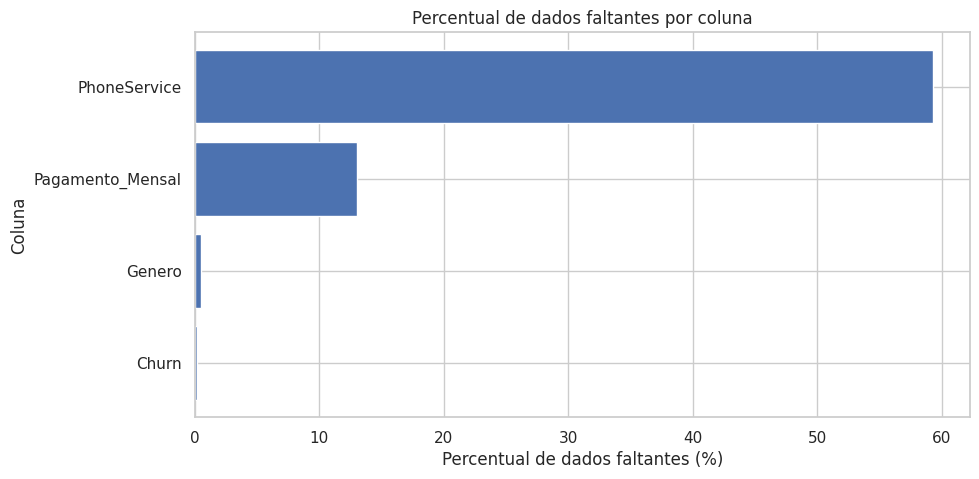

In [9]:
# Gráfico com percentual de dados faltantes por coluna
faltantes_com_nulos = faltantes[faltantes['Qtd_Faltantes'] > 0].sort_values('Percentual_Faltante')

plt.figure(figsize=(10, 5))
plt.barh(faltantes_com_nulos['Coluna'], faltantes_com_nulos['Percentual_Faltante'])
plt.title('Percentual de dados faltantes por coluna')
plt.xlabel('Percentual de dados faltantes (%)')
plt.ylabel('Coluna')
plt.show()

### Análise dos dados faltantes

Foram encontrados dados faltantes em quatro colunas:

* **PhoneService**: possui a maior quantidade de dados faltantes, mais da metade da base.
* **Pagamento_Mensal**: possui uma quantidade relevante de valores ausentes, mas a coluna é importante para análise do perfil financeiro do cliente.
* **Genero**: possui poucos valores ausentes.
* **Churn**: possui poucos valores ausentes, mas é a variável alvo do problema.

Como o objetivo futuro da base é prever churn, a coluna `Churn` é essencial. Linhas sem essa informação não ajudam no treinamento de um modelo supervisionado, pois não sabemos a resposta correta daquele cliente.

## B) Exclusão de colunas ou linhas com dados faltantes

Nesta etapa, analisei quais dados faltantes deveriam ser excluídos. A decisão foi:

* Excluir a coluna **PhoneService**, pois possui muitos valores faltantes. Substituir mais da metade da coluna pela moda poderia distorcer bastante a informação.
* Excluir as linhas em que **Churn** está nulo, pois churn é a variável alvo e não seria correto inventar essa resposta.
* Não excluir as linhas com `Pagamento_Mensal` faltante, porque a coluna é importante e pode ser tratada por imputação.
* Não excluir as linhas com `Genero` faltante, porque a quantidade é pequena e pode ser tratada com moda.

In [10]:
# Criando uma cópia para tratamento, mantendo a base original preservada
df_tratado = df.copy()

# Excluindo a coluna PhoneService pela alta quantidade de valores faltantes
df_tratado = df_tratado.drop(columns=['PhoneService'])

# Excluindo linhas em que a variável alvo Churn está ausente
df_tratado = df_tratado.dropna(subset=['Churn']).reset_index(drop=True)

print(f"Formato da base original: {df.shape}")
print(f"Formato após exclusões: {df_tratado.shape}")

# Conferindo dados faltantes restantes
pd.DataFrame({
    'Qtd_Faltantes': df_tratado.isna().sum(),
    'Percentual_Faltante': (df_tratado.isna().mean() * 100).round(2)
}).sort_values('Percentual_Faltante', ascending=False)

Formato da base original: (2500, 16)
Formato após exclusões: (2495, 15)


,Qtd_Faltantes,Percentual_Faltante
Pagamento_Mensal,320,12.83
Genero,7,0.28
customerID,0,0.00
Casado,0,0.00
Dependents,0,0.00
Tempo_como_Cliente,0,0.00
Idoso,0,0.00
Servico_Internet,0,0.00
Servico_Seguranca,0,0.00
StreamingTV,0,0.00


### Justificativa da exclusão

A exclusão da coluna `PhoneService` foi escolhida porque o percentual de ausência é muito alto. Se eu substituísse todos esses valores pela moda, criaria muitos registros artificiais e poderia fazer o modelo aprender um padrão que não representa a realidade.

Já as linhas com `Churn` nulo foram removidas porque essa coluna representa o resultado que queremos prever futuramente. Como eram poucas linhas, a exclusão não comprometeu o tamanho da base.

## C) Substituição de dados faltantes por média, mediana ou moda

Para definir o melhor método, analisei a distribuição da coluna numérica `Pagamento_Mensal` e observei a frequência das categorias em `Genero`.

In [11]:
# Análise estatística da coluna Pagamento_Mensal antes da imputação
estat_pagamento = df_tratado['Pagamento_Mensal'].describe().to_frame().T
estat_pagamento['mediana'] = df_tratado['Pagamento_Mensal'].median()
estat_pagamento['assimetria'] = df_tratado['Pagamento_Mensal'].skew()
estat_pagamento

,count,mean,std,min,25%,50%,75%,max,mediana,assimetria
Pagamento_Mensal,"2,175.00",65.61,29.93,18.40,39.50,71.45,90.25,118.65,71.45,-0.28


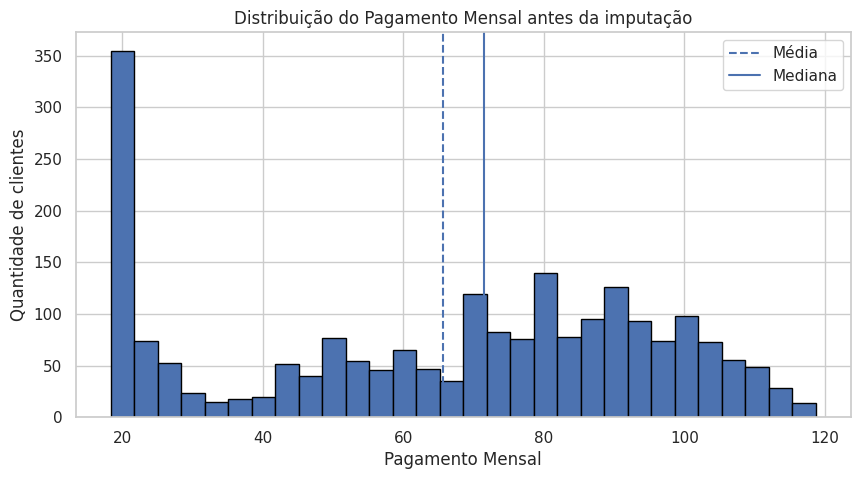

In [12]:
# Visualizando a distribuição do pagamento mensal antes da imputação
plt.figure(figsize=(10, 5))
plt.hist(df_tratado['Pagamento_Mensal'].dropna(), bins=30, edgecolor='black')
plt.axvline(df_tratado['Pagamento_Mensal'].mean(), linestyle='--', label='Média')
plt.axvline(df_tratado['Pagamento_Mensal'].median(), linestyle='-', label='Mediana')
plt.title('Distribuição do Pagamento Mensal antes da imputação')
plt.xlabel('Pagamento Mensal')
plt.ylabel('Quantidade de clientes')
plt.legend()
plt.show()

In [13]:
# Padronizando primeiro as variações de gênero para calcular a moda corretamente
# Isso evita que M, F e f sejam tratados como categorias diferentes de Male/Female.
df_tratado['Genero'] = df_tratado['Genero'].replace({
    'M': 'Male',
    'F': 'Female',
    'f': 'Female'
})

# Verificando a moda de Genero e a mediana de Pagamento_Mensal
moda_genero = df_tratado['Genero'].mode()[0]
mediana_pagamento = df_tratado['Pagamento_Mensal'].median()

print(f"Moda de Genero: {moda_genero}")
print(f"Mediana de Pagamento_Mensal: {mediana_pagamento}")

# Substituindo valores faltantes
df_tratado['Genero'] = df_tratado['Genero'].fillna(moda_genero)
df_tratado['Pagamento_Mensal'] = df_tratado['Pagamento_Mensal'].fillna(mediana_pagamento)

# Conferindo se ainda existem valores faltantes
pd.DataFrame({
    'Qtd_Faltantes': df_tratado.isna().sum(),
    'Percentual_Faltante': (df_tratado.isna().mean() * 100).round(2)
}).sort_values('Percentual_Faltante', ascending=False)

Moda de Genero: Male
Mediana de Pagamento_Mensal: 71.45


,Qtd_Faltantes,Percentual_Faltante
customerID,0,0.00
Genero,0,0.00
Idoso,0,0.00
Casado,0,0.00
Dependents,0,0.00
Tempo_como_Cliente,0,0.00
Servico_Internet,0,0.00
Servico_Seguranca,0,0.00
Suporte_Tecnico,0,0.00
StreamingTV,0,0.00


### Justificativa da substituição

Para `Pagamento_Mensal`, utilizei a **mediana**, porque ela é mais resistente a valores extremos do que a média. Mesmo a distribuição não sendo extremamente distorcida, a mediana representa melhor um valor típico de pagamento mensal.

Para `Genero`, utilizei a **moda**, pois é uma variável categórica. Antes de calcular a moda, corrigi valores como `M`, `F` e `f`, para que não fossem considerados categorias separadas.

Com isso, a base tratada ficou sem valores faltantes nas colunas restantes.

# 3 - Verificação e correção de valores categóricos digitados incorretamente

Nesta etapa, analisei as colunas categóricas para verificar valores escritos com letras maiúsculas/minúsculas diferentes ou nomes inconsistentes.

In [14]:
# Selecionando colunas categóricas da base tratada
colunas_categoricas = df_tratado.select_dtypes(include='object').columns.tolist()

# Verificando os valores únicos em cada coluna categórica
for coluna in colunas_categoricas:
    print(f"\nColuna: {coluna}")
    print(df_tratado[coluna].value_counts(dropna=False))


Coluna: customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6188-UXBBR    1
2333-KWEWW    1
5702-SKUOB    1
1134-YWTYF    1
6061-GWWAV    1
Name: count, Length: 2495, dtype: int64

Coluna: Genero
Genero
Male      1276
Female    1219
Name: count, dtype: int64

Coluna: Casado
Casado
No     1266
Yes    1229
Name: count, dtype: int64

Coluna: Dependents
Dependents
No     1710
Yes     785
Name: count, dtype: int64

Coluna: Servico_Internet
Servico_Internet
Fiber optic    1124
DSL             835
No              528
dsl               8
Name: count, dtype: int64

Coluna: Servico_Seguranca
Servico_Seguranca
No                     1257
Yes                     710
No internet service     528
Name: count, dtype: int64

Coluna: Suporte_Tecnico
Suporte_Tecnico
No                     1254
Yes                     713
No internet service     528
Name: count, dtype: int64

Coluna: StreamingTV
StreamingTV
No                     1003
Yes 

In [15]:
# Removendo espaços antes e depois dos textos nas colunas categóricas
for coluna in colunas_categoricas:
    df_tratado[coluna] = df_tratado[coluna].astype(str).str.strip()

# Corrigindo valores escritos de forma diferente
# Em Genero, já tínhamos corrigido M, F e f na etapa de imputação.
# Em Servico_Internet, havia valores 'dsl' minúsculos que representam a mesma categoria de 'DSL'.
df_tratado['Servico_Internet'] = df_tratado['Servico_Internet'].replace({
    'dsl': 'DSL'
})

# Verificando novamente as principais colunas corrigidas
print("Valores em Genero após tratamento:")
print(df_tratado['Genero'].value_counts())

print("\nValores em Servico_Internet após tratamento:")
print(df_tratado['Servico_Internet'].value_counts())

Valores em Genero após tratamento:
Genero
Male      1276
Female    1219
Name: count, dtype: int64

Valores em Servico_Internet após tratamento:
Servico_Internet
Fiber optic    1124
DSL             843
No              528
Name: count, dtype: int64


In [16]:
# Conferência final dos valores únicos nas colunas categóricas
for coluna in df_tratado.select_dtypes(include='object').columns:
    print(f"\nColuna: {coluna}")
    print(sorted(df_tratado[coluna].unique()))


Coluna: customerID
['0002-ORFBO', '0013-MHZWF', '0013-SMEOE', '0015-UOCOJ', '0017-DINOC', '0019-EFAEP', '0020-INWCK', '0021-IKXGC', '0023-UYUPN', '0030-FNXPP', '0031-PVLZI', '0036-IHMOT', '0040-HALCW', '0042-RLHYP', '0048-LUMLS', '0067-DKWBL', '0074-HDKDG', '0078-XZMHT', '0080-OROZO', '0093-EXYQL', '0094-OIFMO', '0096-FCPUF', '0098-BOWSO', '0104-PPXDV', '0106-GHRQR', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0114-IGABW', '0114-RSRRW', '0115-TFERT', '0121-SNYRK', '0122-OAHPZ', '0123-CRBRT', '0125-LZQXK', '0129-QMPDR', '0134-XWXCE', '0135-NMXAP', '0139-IVFJG', '0141-YEAYS', '0142-GVYSN', '0151-ONTOV', '0177-PXBAT', '0178-SZBHO', '0181-RITDD', '0187-WZNAB', '0191-ZHSKZ', '0195-IESCP', '0196-JTUQI', '0201-OAMXR', '0206-TBWLC', '0207-MDKNV', '0214-JHPFW', '0215-BQKGS', '0219-QAERP', '0219-YTZUE', '0221-WMXNQ', '0222-CNVPT', '0224-HJAPT', '0224-RLWWD', '0229-LFJAF', '0230-WEQUW', '0234-TEVTT', '0235-KGSLC', '0236-HFWSV', '0248-IPDFW', '0256-LTHVJ', '0257-ZESQC', '0259-GBZSH', '0265-EDXBD',

### Análise das correções categóricas

Foram encontradas inconsistências principalmente em duas colunas:

* `Genero`: existiam valores como `M`, `F` e `f`, que foram padronizados para `Male` e `Female`.
* `Servico_Internet`: existia o valor `dsl` em minúsculo, que foi corrigido para `DSL`.

Esse tipo de ajuste é importante porque, para o Python e para um futuro modelo, `DSL` e `dsl` seriam categorias diferentes, mesmo representando a mesma informação. O mesmo aconteceria com `Female`, `F` e `f`.

# [EXTRA] 4 - Padronização dos nomes das colunas

Como a base possui colunas em português e em inglês, optei por padronizar os nomes das colunas para português. Isso facilita a leitura e deixa a base mais organizada para as próximas etapas.

In [17]:
# Renomeando as colunas para manter um padrão em português
df_tratado = df_tratado.rename(columns={
    'customerID': 'ID_Cliente',
    'Genero': 'Genero',
    'Idoso': 'Idoso',
    'Casado': 'Casado',
    'Dependents': 'Dependentes',
    'Tempo_como_Cliente': 'Tempo_como_Cliente',
    'Servico_Internet': 'Servico_Internet',
    'Servico_Seguranca': 'Servico_Seguranca',
    'Suporte_Tecnico': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'Tipo_Contrato': 'Tipo_Contrato',
    'PaymentMethod': 'Metodo_Pagamento',
    'Pagamento_Mensal': 'Pagamento_Mensal',
    'Total_Pago': 'Total_Pago',
    'Churn': 'Churn'
})

# Visualizando as primeiras linhas da base final tratada
df_tratado.head()

,ID_Cliente,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,Streaming_TV,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,DSL,Yes,No,No,One year,Mailed check,56.95,"1,889.50",No
2,3668-QPYBK,Male,0,No,No,2,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,"1,840.75",No
4,9237-HQITU,Male,0,No,No,2,Fiber optic,No,No,No,Month-to-month,Electronic check,71.45,151.65,Yes


In [18]:
# Conferência final da base tratada
print(f"Formato final da base tratada: {df_tratado.shape}")
print(f"Total de dados faltantes na base final: {df_tratado.isna().sum().sum()}")

resumo_final = pd.DataFrame({
    'Coluna': df_tratado.columns,
    'Tipo_Dado': df_tratado.dtypes.astype(str).values,
    'Qtd_Faltantes': df_tratado.isna().sum().values,
    'Qtd_Valores_Unicos': df_tratado.nunique(dropna=False).values
})

resumo_final

Formato final da base tratada: (2495, 15)
Total de dados faltantes na base final: 0


,Coluna,Tipo_Dado,Qtd_Faltantes,Qtd_Valores_Unicos
0,ID_Cliente,object,0,2495
1,Genero,object,0,2
2,Idoso,Int64,0,2
3,Casado,object,0,2
4,Dependentes,object,0,2
5,Tempo_como_Cliente,int64,0,73
6,Servico_Internet,object,0,3
7,Servico_Seguranca,object,0,3
8,Suporte_Tecnico,object,0,3
9,Streaming_TV,object,0,3


In [19]:
# Salvando a base tratada para uso nas próximas etapas de modelagem
df_tratado.to_csv('CHURN_TELECON_MOD08_TAREFA_TRATADO.csv', index=False, encoding='utf-8-sig')

print("Arquivo CHURN_TELECON_MOD08_TAREFA_TRATADO.csv salvo com sucesso.")

Arquivo CHURN_TELECON_MOD08_TAREFA_TRATADO.csv salvo com sucesso.


# Conclusão

Neste pré-processamento, a base de churn de telecomunicações foi carregada, analisada e tratada para ficar mais adequada para uma etapa futura de modelagem.

As principais decisões foram:

* A coluna `PhoneService` foi removida porque tinha muitos valores faltantes, e preencher mais da metade da coluna poderia distorcer a informação.
* As linhas sem `Churn` foram removidas, porque `Churn` é a variável alvo e não faria sentido criar esse valor artificialmente.
* Os valores ausentes de `Pagamento_Mensal` foram preenchidos com a mediana, por ser uma medida mais robusta para variável numérica.
* Os valores ausentes de `Genero` foram preenchidos com a moda, por ser uma variável categórica.
* Foram corrigidas inconsistências em variáveis categóricas, como `M`, `F`, `f` e `dsl`.
* Os nomes das colunas foram padronizados para facilitar a leitura.

Ao final, a base ficou sem dados faltantes nas colunas utilizadas e mais consistente para as próximas etapas, como análise exploratória, codificação de variáveis categóricas e criação de um modelo de previsão de churn.